In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_base_dataset(seed, n_samples=200):
    np.random.seed(seed)
    X_class1 = np.random.multivariate_normal(mean=[3, 3], cov=[[0.75, 0], [0, 0.75]], size=n_samples // 2)
    X_class2 = np.random.multivariate_normal(mean=[-3, -3], cov=[[0.75, 0], [0, 0.75]], size=n_samples // 2)
    X = np.vstack([X_class1, X_class2])
    y = np.array([1] * (n_samples // 2) + [-1] * (n_samples // 2))
    return X, y

def add_uniform_label_noise(y, noise_ratio=0.1):
    n_noise = int(len(y) * noise_ratio)
    noise_indices = np.random.choice(len(y), n_noise, replace=False)
    y_noisy = y.copy()
    y_noisy[noise_indices] *= -1
    return y_noisy

def add_gaussian_label_noise(X, y, noise_scale=1.0):
    y_noisy = y.copy()
    distances = np.linalg.norm(X, axis=1)
    prob_flip = 1 / (1 + np.exp(-distances / noise_scale))
    random_values = np.random.rand(len(y))
    flip_indices = random_values < prob_flip * 0.5
    y_noisy[flip_indices] *= -1
    return y_noisy

def add_feature_noise(X, noise_std=0.5):
    noise = np.random.normal(loc=0.0, scale=noise_std, size=X.shape)
    return X + noise

def add_outliers(X, y, n_outliers=5, outlier_distance=10):
    X_outliers = np.random.uniform(low=-outlier_distance, high=outlier_distance, size=(n_outliers, X.shape[1]))
    y_outliers = np.random.choice([-1, 1], size=n_outliers)
    X_augmented = np.vstack([X, X_outliers])
    y_augmented = np.concatenate([y, y_outliers])
    return X_augmented, y_augmented

datasets = {
    "clean": [],
    "clean_outliers": [],
    "uniform_target_noise": [],
    "gaussian_target_noise": [],
    "feature_noise": [],
    "uniform_target_noise_outliers": [],
    "gaussian_target_noise_outliers": [],
    "feature_noise_outliers": []
}


label_noise_ratio = 0.1
feature_noise_std = 0.75

for seed in range(5):
    X, y = generate_base_dataset(seed)

    y_uniform_noise = add_uniform_label_noise(y, noise_ratio=label_noise_ratio)
    y_gaussian_noise = add_gaussian_label_noise(X, y, noise_scale=3.0)
    X_feature_noise = add_feature_noise(X, noise_std=feature_noise_std)

    datasets["clean"].append((X.copy(), y.copy()))
    datasets["clean_outliers"].append(add_outliers(X.copy(), y.copy()))
    datasets["uniform_target_noise"].append((X.copy(), y_uniform_noise))
    datasets["gaussian_target_noise"].append((X.copy(), y_gaussian_noise))
    datasets["feature_noise"].append((X_feature_noise, y.copy()))
    datasets["uniform_target_noise_outliers"].append(add_outliers(X.copy(), y_uniform_noise))
    datasets["gaussian_target_noise_outliers"].append(add_outliers(X.copy(), y_gaussian_noise))
    datasets["feature_noise_outliers"].append(add_outliers(X_feature_noise.copy(), y.copy()))


print("All datasets generated including feature noise variations.")


✅ All datasets generated including feature noise variations.


In [ ]:
def compute_bias(X, y, alpha_eff, support_threshold=1e-4):
    support_indices = np.where(np.abs(alpha_eff) > support_threshold)[0]
    X_sv = X[support_indices]
    y_sv = y[support_indices]
    alpha_sv = alpha_eff[support_indices]

    b_values = []
    for i in support_indices:
        k = X_sv @ X[i]
        margin = np.sum(alpha_sv * y_sv * k)
        b_values.append(y[i] - margin)

    return np.mean(b_values) if b_values else 0.0


def predict(X_train, y_train, alpha, b, X_test):
    K = X_train @ X_test.T
    decision = ((alpha * y_train).reshape(1, -1) @ K).flatten() + b
    return decision

In [ ]:
import numpy as np
from cvxopt import matrix, solvers

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from numpy.linalg import norm

matplotlib.rcParams['figure.dpi'] = 120

def compute_angle_deviation(w1, w2):
    if norm(w1) == 0 or norm(w2) == 0:
        return np.nan
    cos_sim = np.dot(w1, w2) / (norm(w1) * norm(w2))
    cos_sim = np.clip(cos_sim, -1.0, 1.0)
    return np.degrees(np.arccos(cos_sim))

# HINGE

In [ ]:
def hinge_svm_dual(X, y, C=1.0, kernel='linear', epsilon=1e-8):
    n_samples = X.shape[0]

    if kernel == 'linear':
        K = X @ X.T
    else:
        raise NotImplementedError("Only linear kernel implemented")

    Y = y.reshape(-1, 1)
    Q = (Y @ Y.T) * K + epsilon * np.eye(n_samples)

    P = matrix(Q)
    q = matrix(-np.ones(n_samples))

    G = matrix(np.vstack([-np.eye(n_samples), np.eye(n_samples)]))
    h = matrix(np.hstack([np.zeros(n_samples), np.ones(n_samples) * C]))

    A = matrix(y.reshape(1, -1).astype('double'))
    b_qp = matrix(np.array([0.0]))

    solvers.options['show_progress'] = False
    sol = solvers.qp(P, q, G, h, A, b_qp)

    if sol['status'] != 'optimal':
        print("Warning: Hinge SVM did not converge.")
        return None, None

    alpha = np.array(sol['x']).flatten()
    b = compute_bias(X, y, alpha)
    return alpha, b

In [ ]:
C_exp_range = range(-18, 19, 2)
hyperparams_to_test = [2**i for i in C_exp_range]
kernel = 'linear'
dataset_names = list(datasets.keys())

angle_deviation_results = {C: {name: [] for name in dataset_names} for C in hyperparams_to_test}

for C in hyperparams_to_test:
    for name in dataset_names:
        for seed in range(5):
            X_cur, y_cur = datasets[name][seed]
            X_clean, y_clean = datasets["clean"][seed]

            alpha_cur, b_cur = hinge_svm_dual(X_cur, y_cur, C)
            if alpha_cur is None:
                print(f"Seed {seed}: Noisy data optimization failed.")
                angle_deviation_results[C][name].append(None)
                continue

            alpha_clean, b_clean = hinge_svm_dual(X_clean, y_clean, C)
            if alpha_clean is None:
                print(f"Seed {seed}: Clean data optimization failed.")
                angle_deviation_results[C][name].append(None)
                continue

            w_cur = np.sum((alpha_cur * y_cur)[:, None] * X_cur, axis=0)
            w_clean = np.sum((alpha_clean * y_clean)[:, None] * X_clean, axis=0)

            if np.any(np.isnan(w_cur)) or np.any(np.isnan(w_clean)):
                print(f"Seed {seed}: Invalid weight vector (NaN encountered).")
                angle_deviation_results[C][name].append(None)
                continue

            angle_diff = compute_angle_deviation(w_clean, w_cur)
            angle_deviation_results[C][name].append(angle_diff)

mean_angle_results = {}

for name in dataset_names:
    all_angles = []
    for C in hyperparams_to_test:
        all_angles.extend([v for v in angle_deviation_results[C][name] if v is not None])
    mean_angle_results[name] = np.mean(all_angles) if all_angles else None

print("\nMean Angular Deviation (Noisy vs Clean):")
for name, mean_angle in mean_angle_results.items():
    print(f"{name}: {mean_angle:.2f}" if mean_angle is not None else f"{name}: N/A")



Mean Angular Deviation (Noisy vs Clean):
clean: 0.00
clean_outliers: 9.03
uniform_target_noise: 5.97
gaussian_target_noise: 23.99
feature_noise: 4.99
uniform_target_noise_outliers: 7.21
gaussian_target_noise_outliers: 17.38
feature_noise_outliers: 15.55


In [ ]:
print("\n==== Best C (with min Avg Angular Deviation) for each Dataset ====")
best_C_table = []
for name in dataset_names:
    best_C = None
    best_deviation = float('inf')

    for C in hyperparams_to_test:
        deviations = angle_deviation_results[C][name]
        valid_devs = [d for d in deviations if d is not None]
        if valid_devs:
            avg_dev = np.mean(valid_devs)
            if avg_dev < best_deviation:
                best_deviation = avg_dev
                best_C = C

    best_C_table.append([name.replace("_", " ").title(), best_C, f"{best_deviation:.2f}°" if best_C is not None else "N/A"])

from tabulate import tabulate
print(tabulate(best_C_table, headers=["Dataset", "Best C", "Min Avg Deviation"], tablefmt="fancy_grid"))



==== Best C (with min Avg Angular Deviation) for each Dataset ====
╒════════════════════════════════╤═════════════╤═════════════════════╕
│ Dataset                        │      Best C │ Min Avg Deviation   │
╞════════════════════════════════╪═════════════╪═════════════════════╡
│ Clean                          │ 1.52588e-05 │ 0.00°               │
├────────────────────────────────┼─────────────┼─────────────────────┤
│ Clean Outliers                 │ 0.000244141 │ 0.92°               │
├────────────────────────────────┼─────────────┼─────────────────────┤
│ Uniform Target Noise           │ 3.8147e-06  │ 0.65°               │
├────────────────────────────────┼─────────────┼─────────────────────┤
│ Gaussian Target Noise          │ 0.000976562 │ 5.95°               │
├────────────────────────────────┼─────────────┼─────────────────────┤
│ Feature Noise                  │ 3.8147e-06  │ 0.26°               │
├────────────────────────────────┼─────────────┼─────────────────────┤
│ Uniform

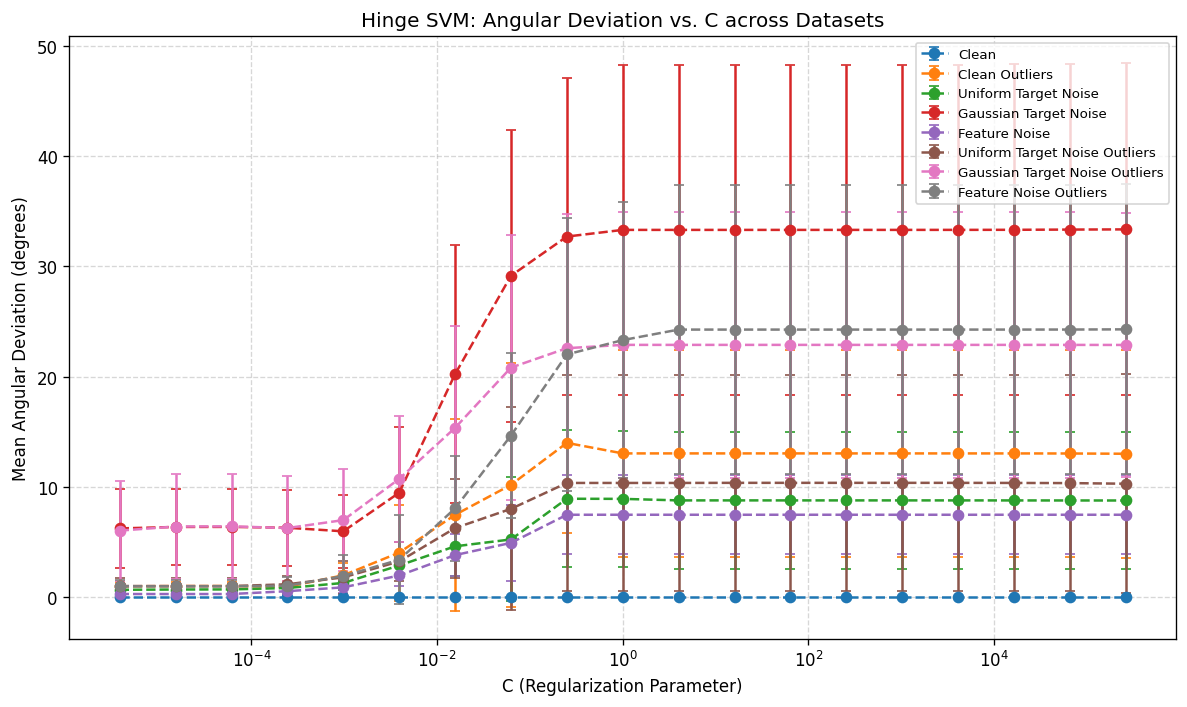

In [ ]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))

for dataset in dataset_names:
    mean_devs = []
    std_devs = []

    for C in hyperparams_to_test:
        deviations = angle_deviation_results[C][dataset]
        deviations = [d for d in deviations if d is not None]
        if deviations:
            mean_devs.append(np.mean(deviations))
            std_devs.append(np.std(deviations))
        else:
            mean_devs.append(np.nan)
            std_devs.append(0)

    plt.errorbar(hyperparams_to_test, mean_devs, yerr=std_devs,
                 label=dataset.replace('_', ' ').title(),
                 marker='o', capsize=3, linestyle='--')

plt.xscale('log')
plt.xlabel("C (Regularization Parameter)")
plt.ylabel("Mean Angular Deviation (degrees)")
plt.title("Hinge SVM: Angular Deviation vs. C across Datasets")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()

os.makedirs("hinge_plot", exist_ok=True)
plt.savefig("hinge_plot/hinge_svm_synthetic_deviation_vs_C.png", dpi=300)

plt.show()


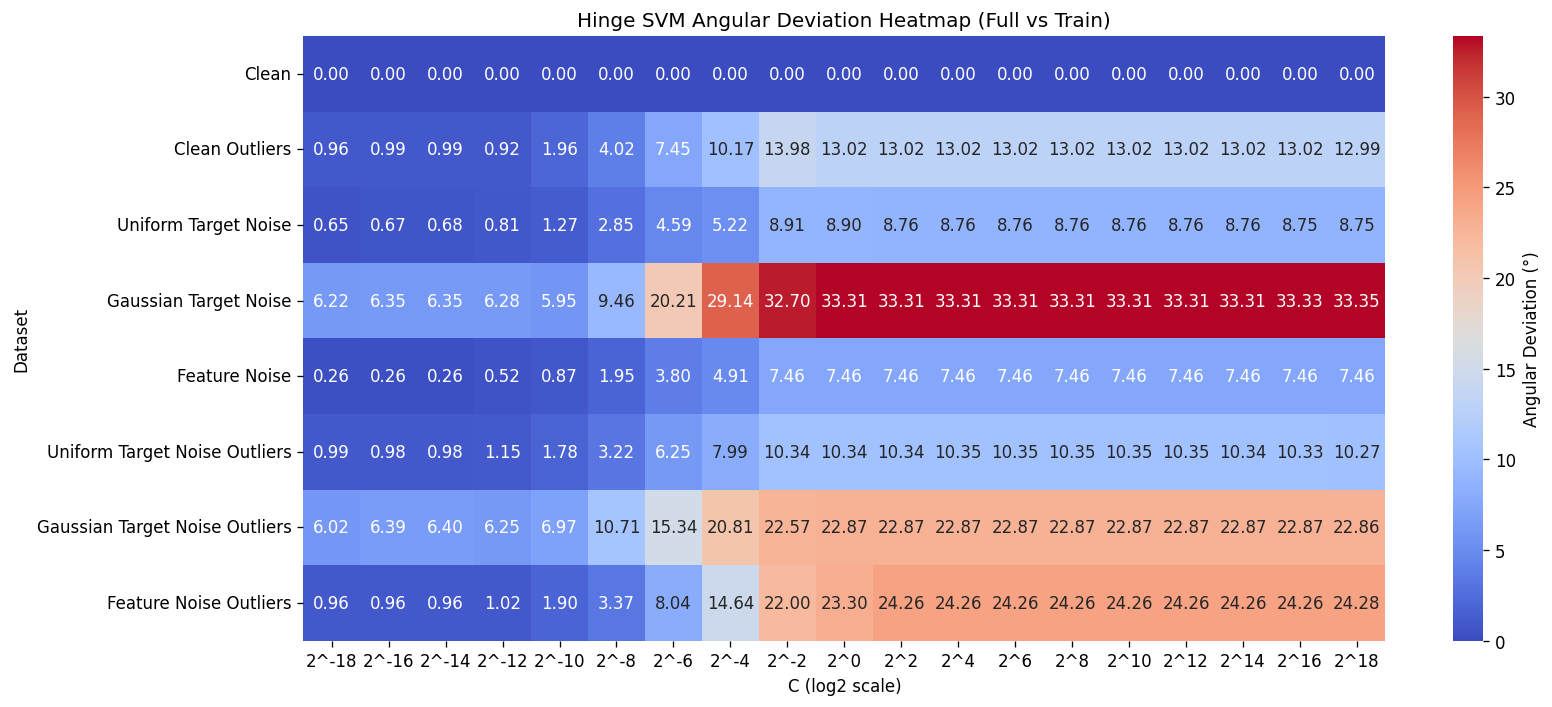

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

heatmap_data = pd.DataFrame(
    index=[name.replace('_', ' ').title() for name in dataset_names],
    columns=[f"2^{i}" for i in C_exp_range]
)

for i, C in enumerate(hyperparams_to_test):
    for name in dataset_names:
        deviations = angle_deviation_results[C][name]
        valid_devs = [d for d in deviations if d is not None]
        avg_dev = np.mean(valid_devs) if valid_devs else np.nan
        heatmap_data.loc[name.replace('_', ' ').title(), f"2^{C_exp_range[i]}"] = avg_dev

heatmap_data = heatmap_data.astype(float)

plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_data, annot=True, fmt=".2f", cmap="coolwarm",
    cbar_kws={'label': 'Angular Deviation (°)'}
)

plt.title("Hinge SVM Angular Deviation Heatmap (Full vs Train)")
plt.xlabel("C (log2 scale)")
plt.ylabel("Dataset")
plt.tight_layout()
os.makedirs("hinge_heatmap", exist_ok=True)
plt.savefig("hinge_heatmap/hinge_svm_combined_deviation_heatmap.png", dpi=300)
plt.show()


# PINBALL

In [ ]:
def pinball_svm_dual(X, y, C=1.0, tau=0.5, kernel='linear'):
    n = X.shape[0]

    if kernel == 'linear':
        K = X @ X.T
    else:
        raise NotImplementedError("Only linear kernel is implemented")

    Y = y.reshape(-1, 1)
    Q = (Y @ Y.T) * K

    H = np.block([
        [ Q, -Q ],
        [ -Q, Q ]
    ])

    c = np.hstack([-1 * np.ones(n), 1 * np.ones(n)])

    Aeq = np.hstack([y, -y]).reshape(1, -1)
    beq = np.array([0.0])

    A2 = np.zeros((n, 2*n))
    A2[np.arange(n), np.arange(n)] = 1
    A2[np.arange(n), np.arange(n) + n] = 1/tau
    b2 = np.ones(n) * C

    A_combined = np.vstack([Aeq, A2])
    b_combined = np.hstack([beq, b2])

    A = matrix(A_combined.astype(np.float64))
    b = matrix(b_combined.astype(np.float64))


    G = -np.eye(2 * n)
    h = np.zeros(2 * n)

    P = matrix(H)
    q = matrix(c)
    G = matrix(G)
    h = matrix(h)
    A = matrix(A_combined)
    b = matrix(b_combined)

    solvers.options['show_progress'] = False
    sol = solvers.qp(P, q, G, h, A, b)

    result = np.array(sol['x']).flatten()
    alpha, beta = result[:n], result[n:]
    return alpha, beta


In [ ]:
dataset_names = list(datasets.keys())

In [ ]:
C_exp_range = range(-18, 19, 2)
C_values = [2 ** i for i in C_exp_range]
tau_values = np.round(np.arange(0.1, 1.0 + 0.1, 0.1), 2)


pinball_results = {
    name: {
        tau: {C: [] for C in C_values}
        for tau in tau_values
    } for name in dataset_names
}


for name in dataset_names:
    for tau in tau_values:
        for C in C_values:
            for seed in range(5):
                X_cur, y_cur = datasets[name][seed]
                X_clean, y_clean = datasets["clean"][seed]

                try:
                    alpha_cur, beta_cur = pinball_svm_dual(X_cur, y_cur, C, tau)
                    alpha_eff_cur = beta_cur - alpha_cur
                    b_cur = compute_bias(X_cur, y_cur, alpha_eff_cur)
                    w_cur = np.sum((alpha_eff_cur * y_cur)[:, None] * X_cur, axis=0)

                    alpha_clean, beta_clean = pinball_svm_dual(X_clean, y_clean, C, tau)
                    alpha_eff_clean = beta_clean - alpha_clean
                    b_clean = compute_bias(X_clean, y_clean, alpha_eff_clean)
                    w_clean = np.sum((alpha_eff_clean * y_clean)[:, None] * X_clean, axis=0)

                    angle_diff = compute_angle_deviation(w_clean, w_cur)
                except:
                    angle_diff = None

                pinball_results[name][tau][C].append(angle_diff)

mean_angle_results = {}

for name in dataset_names:
    all_devs = []
    for tau in tau_values:
        for C in C_values:
            deviations = pinball_results[name][tau][C]
            all_devs.extend([d for d in deviations if d is not None])
    mean_angle_results[name] = np.mean(all_devs) if all_devs else None

print("\nMean Angular Deviation (Noisy vs Clean):")
for name in dataset_names:
    mean = mean_angle_results[name]
    print(f"{name}: {mean:.2f}" if mean is not None else f"{name}: N/A")



Mean Angular Deviation (Noisy vs Clean):
clean: 0.00
clean_outliers: 4.06
uniform_target_noise: 2.84
gaussian_target_noise: 16.89
feature_noise: 3.10
uniform_target_noise_outliers: 3.12
gaussian_target_noise_outliers: 13.37
feature_noise_outliers: 4.68


In [ ]:
summary_table = []
for name in dataset_names:
    best_dev = float('inf')
    best_C = best_tau = None

    for C in C_values:
        for tau in tau_values:
            deviations = pinball_results[name][tau][C]
            valid_devs = [d for d in deviations if d is not None]
            avg_dev = np.mean(valid_devs) if valid_devs else np.nan
            if not np.isnan(avg_dev) and avg_dev < best_dev:
                best_dev = avg_dev
                best_C = C
                best_tau = tau

    summary_table.append([name.replace('_', ' ').title(), best_C, best_tau, f"{best_dev:.2f}°"])

print("\n=== Best Hyperparameters per Dataset ===")
from tabulate import tabulate
print(tabulate(summary_table, headers=["Dataset", "Best C", "Best τ", "Min Avg Deviation"], tablefmt="fancy_grid"))



=== Best Hyperparameters per Dataset ===
╒════════════════════════════════╤═════════════╤══════════╤═════════════════════╕
│ Dataset                        │      Best C │   Best τ │ Min Avg Deviation   │
╞════════════════════════════════╪═════════════╪══════════╪═════════════════════╡
│ Clean                          │ 3.8147e-06  │      0.1 │ 0.00°               │
├────────────────────────────────┼─────────────┼──────────┼─────────────────────┤
│ Clean Outliers                 │ 0.000976562 │      1   │ 0.78°               │
├────────────────────────────────┼─────────────┼──────────┼─────────────────────┤
│ Uniform Target Noise           │ 3.8147e-06  │      1   │ 0.56°               │
├────────────────────────────────┼─────────────┼──────────┼─────────────────────┤
│ Gaussian Target Noise          │ 0.000976562 │      0.6 │ 5.81°               │
├────────────────────────────────┼─────────────┼──────────┼─────────────────────┤
│ Feature Noise                  │ 3.8147e-06  │      0.

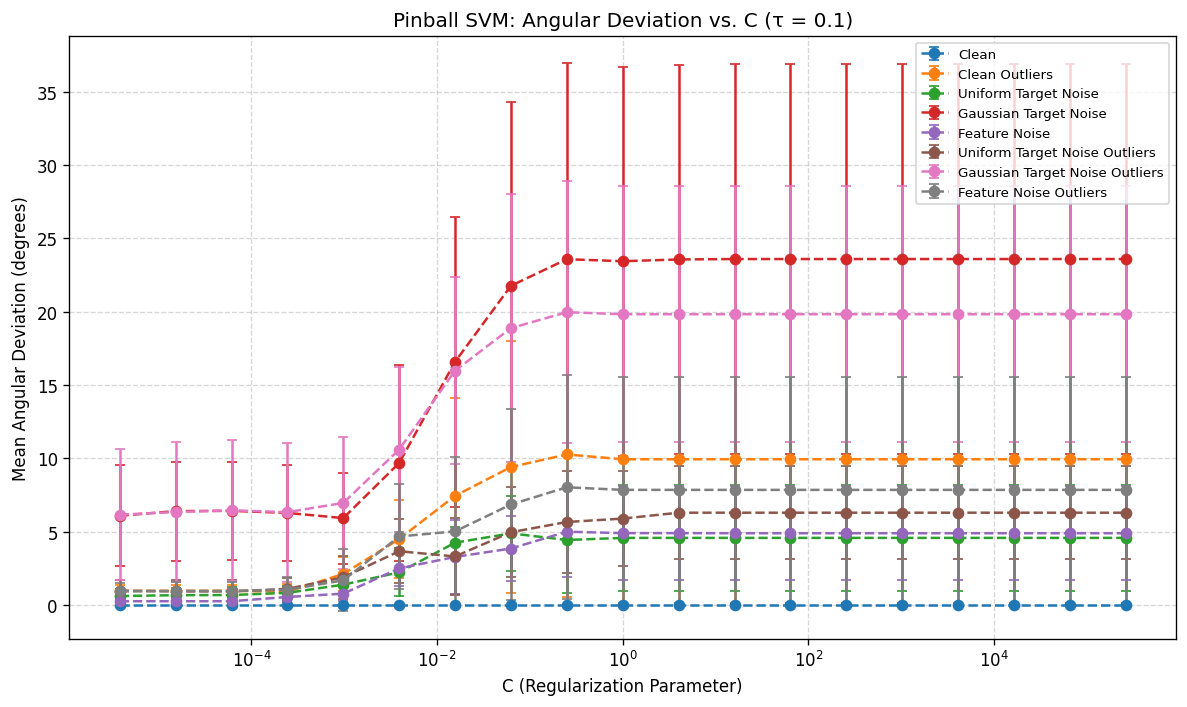

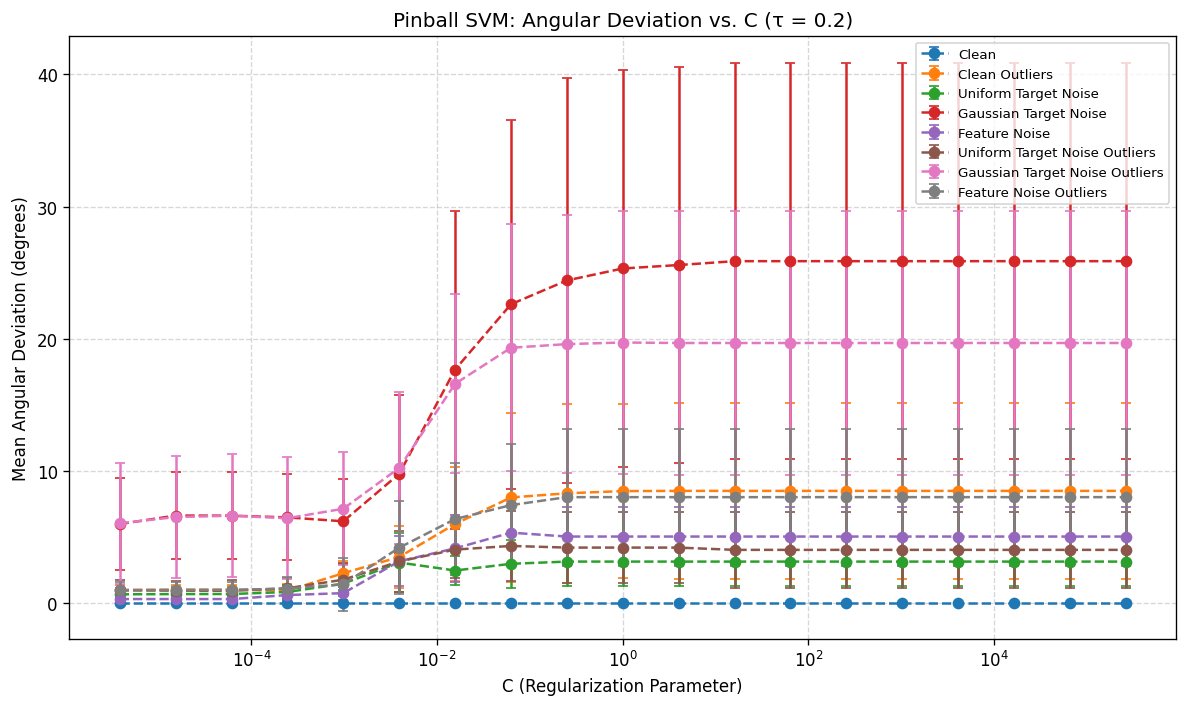

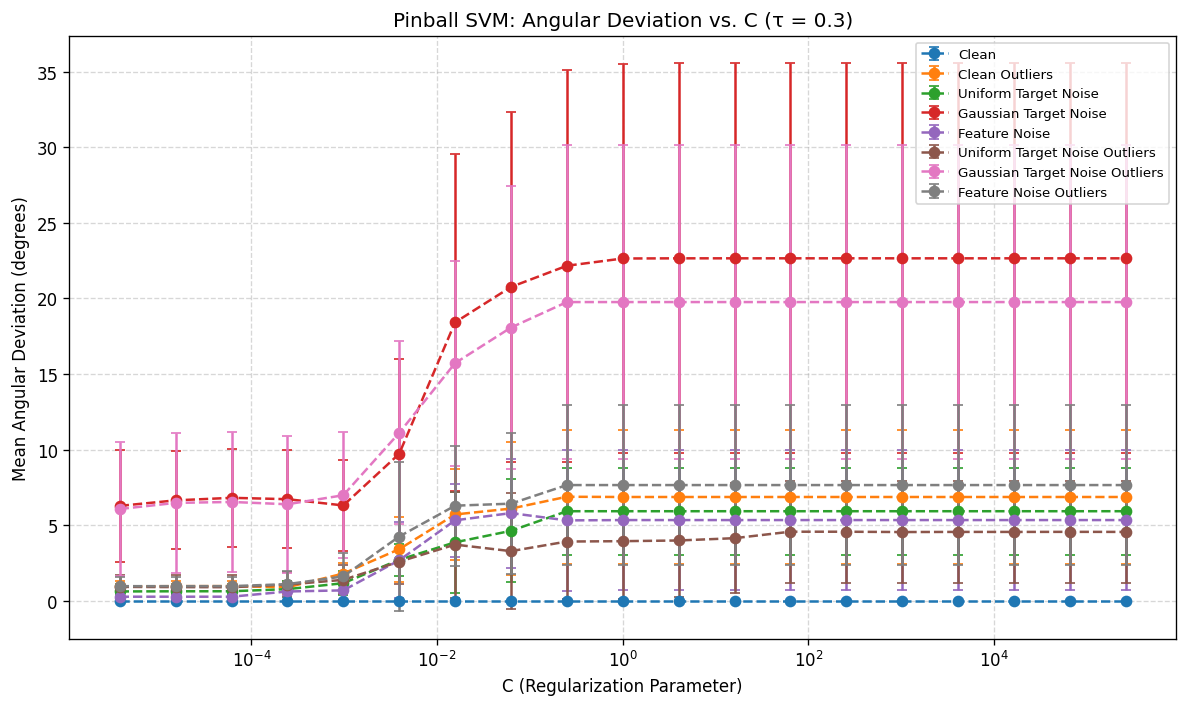

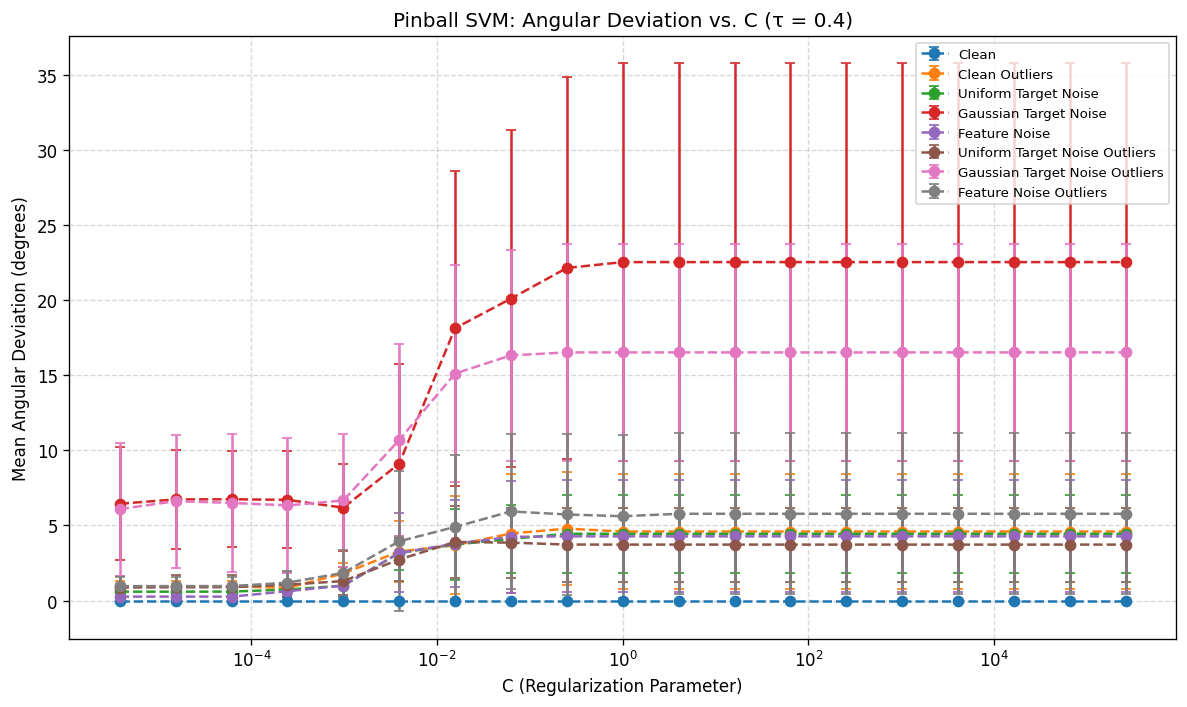

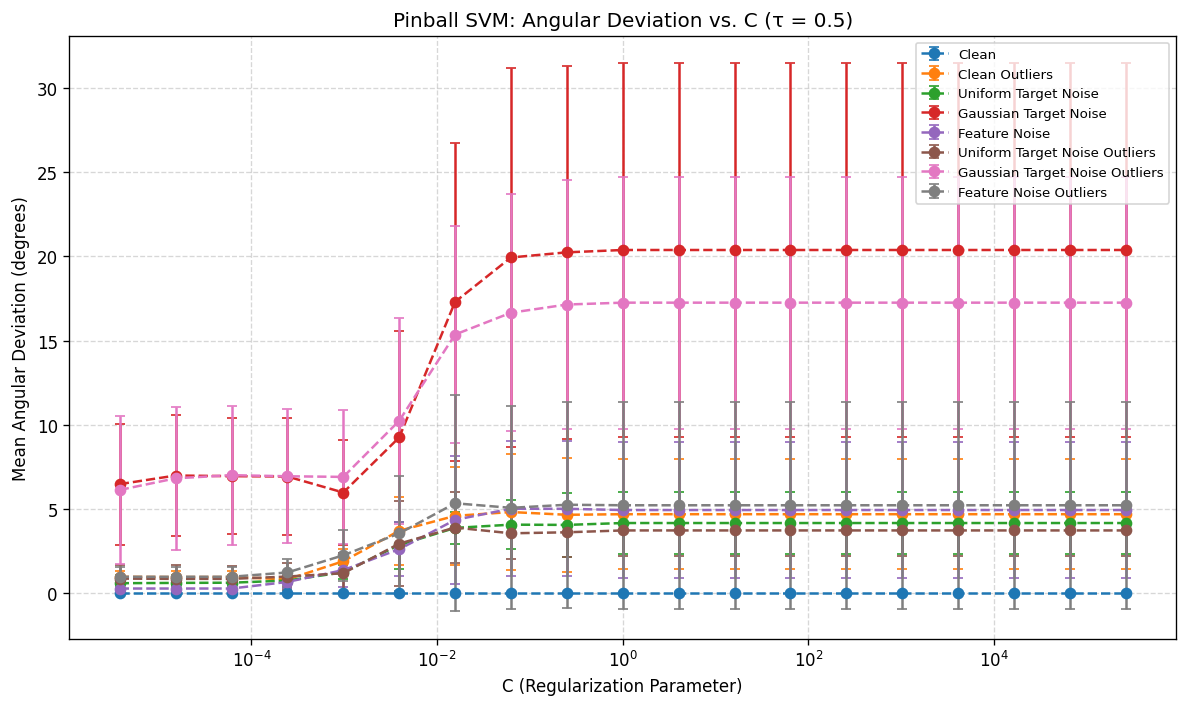

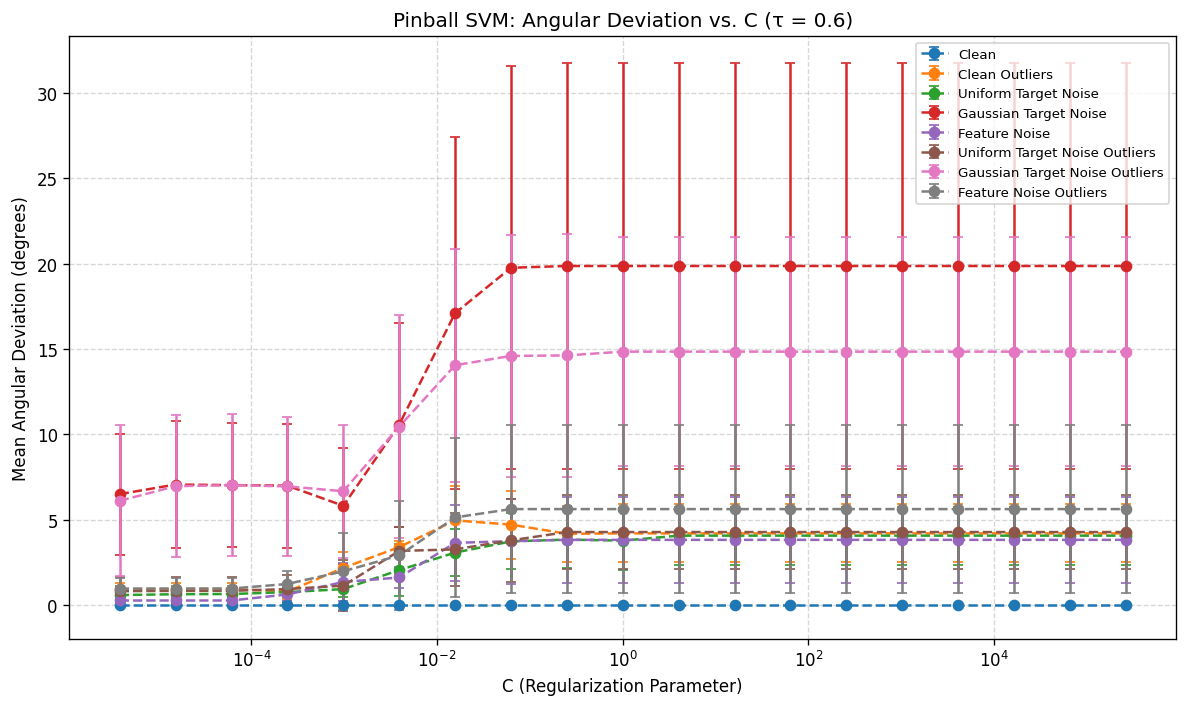

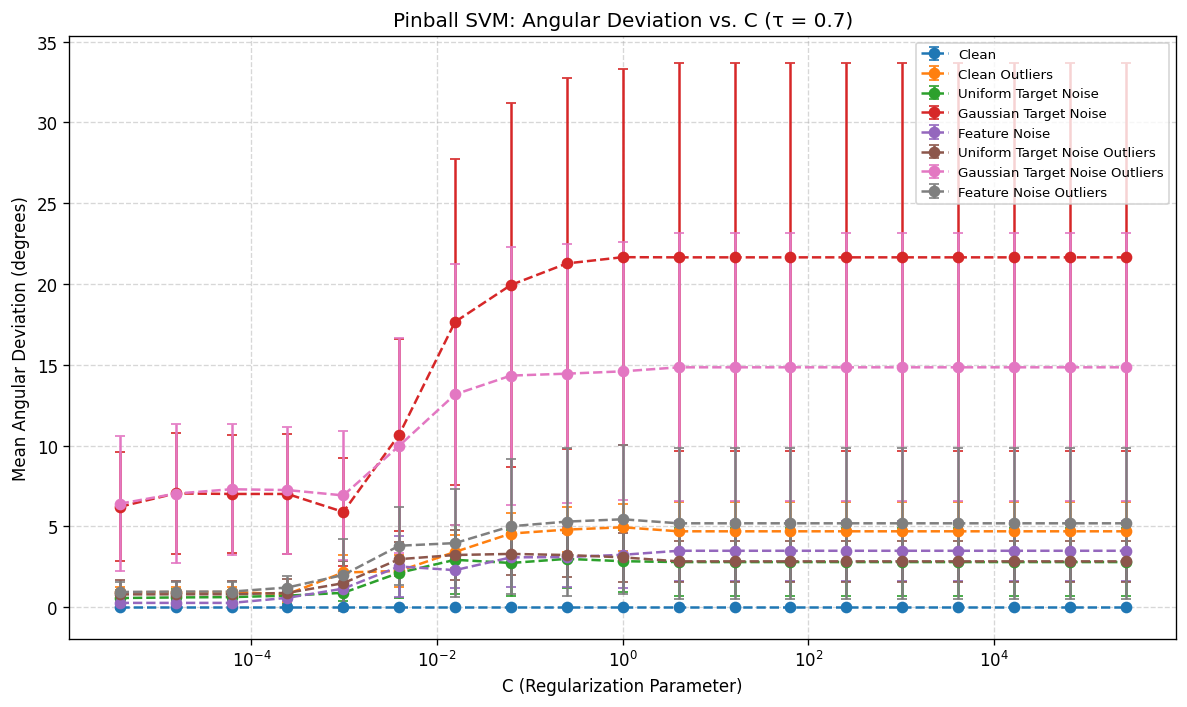

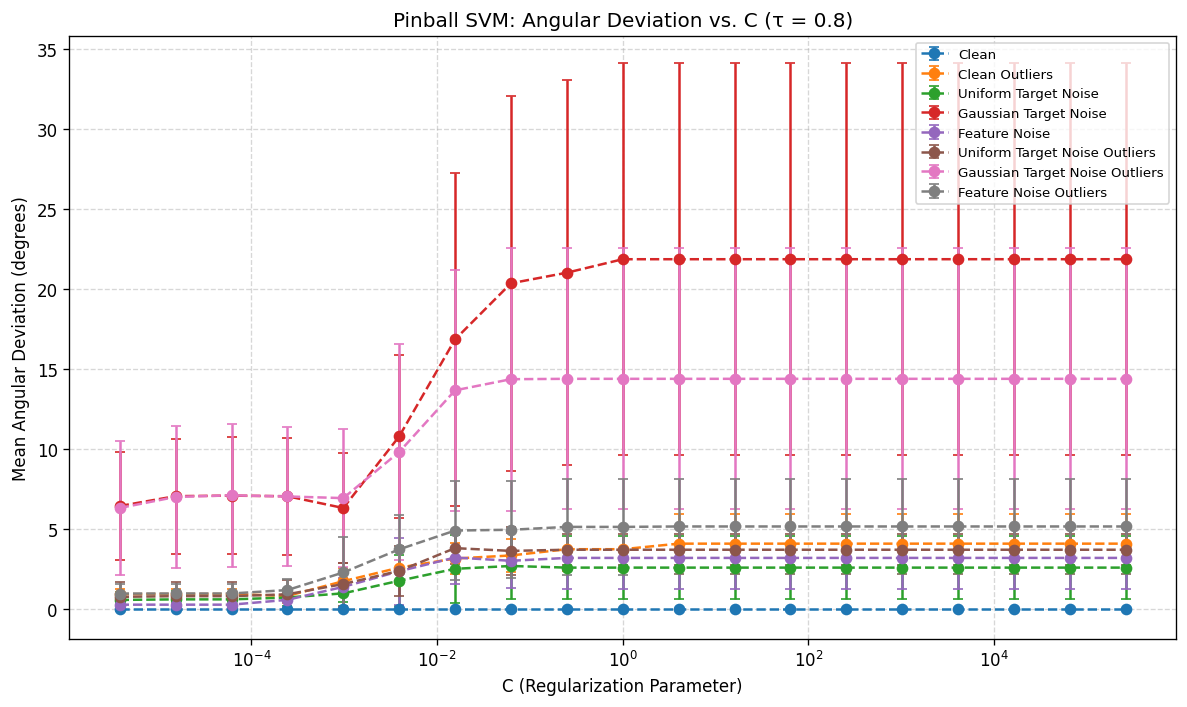

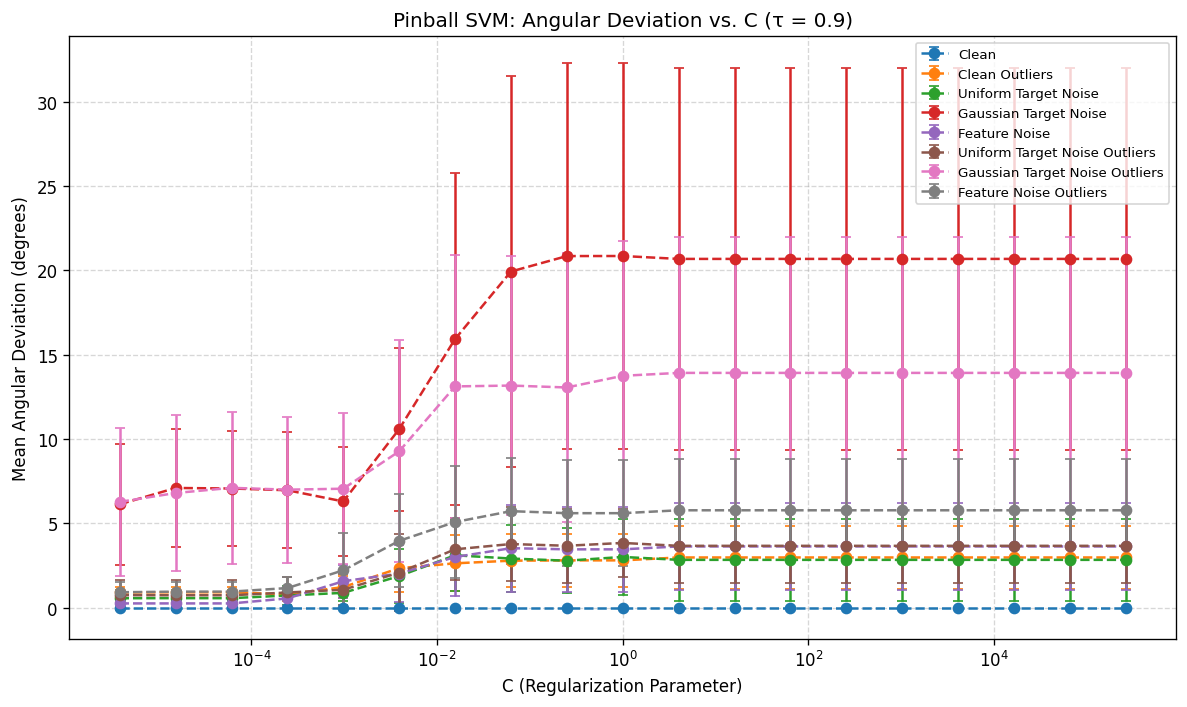

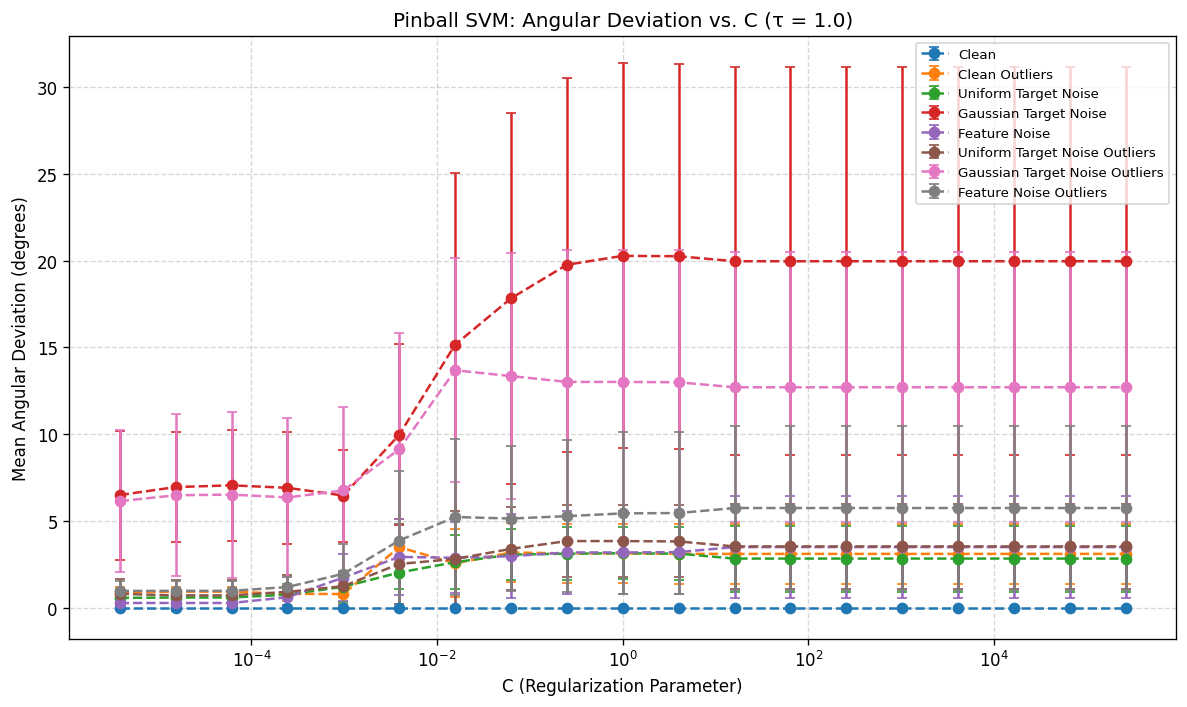

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

for tau in tau_values:
    plt.figure(figsize=(10, 6))

    for name in dataset_names:
        mean_devs = []
        std_devs = []

        for C in C_values:
            deviations = pinball_results[name][tau][C]
            if deviations:
                deviations = [a for a in deviations if a is not None]
                mean_devs.append(np.mean(deviations))
                std_devs.append(np.std(deviations))
            else:
                mean_devs.append(np.nan)
                std_devs.append(0)

        plt.errorbar(C_values, mean_devs, yerr=std_devs,
                     label=name.replace('_', ' ').title(),
                     marker='o', capsize=3, linestyle='--')

    plt.xscale("log")
    plt.xlabel("C (Regularization Parameter)")
    plt.ylabel("Mean Angular Deviation (degrees)")
    plt.title(f"Pinball SVM: Angular Deviation vs. C (τ = {tau})")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right', fontsize=8)
    plt.tight_layout()

    os.makedirs("pinball_plots", exist_ok=True)
    plt.savefig(f"pinball_plots/pinball_svm_synthetic_deviation_vs_C_tau_{tau}.png", dpi=300)
    plt.show()


→ Best Params for Clean: C = 3.814697265625e-06, τ = 0.1, Min Deviation = 0.00°


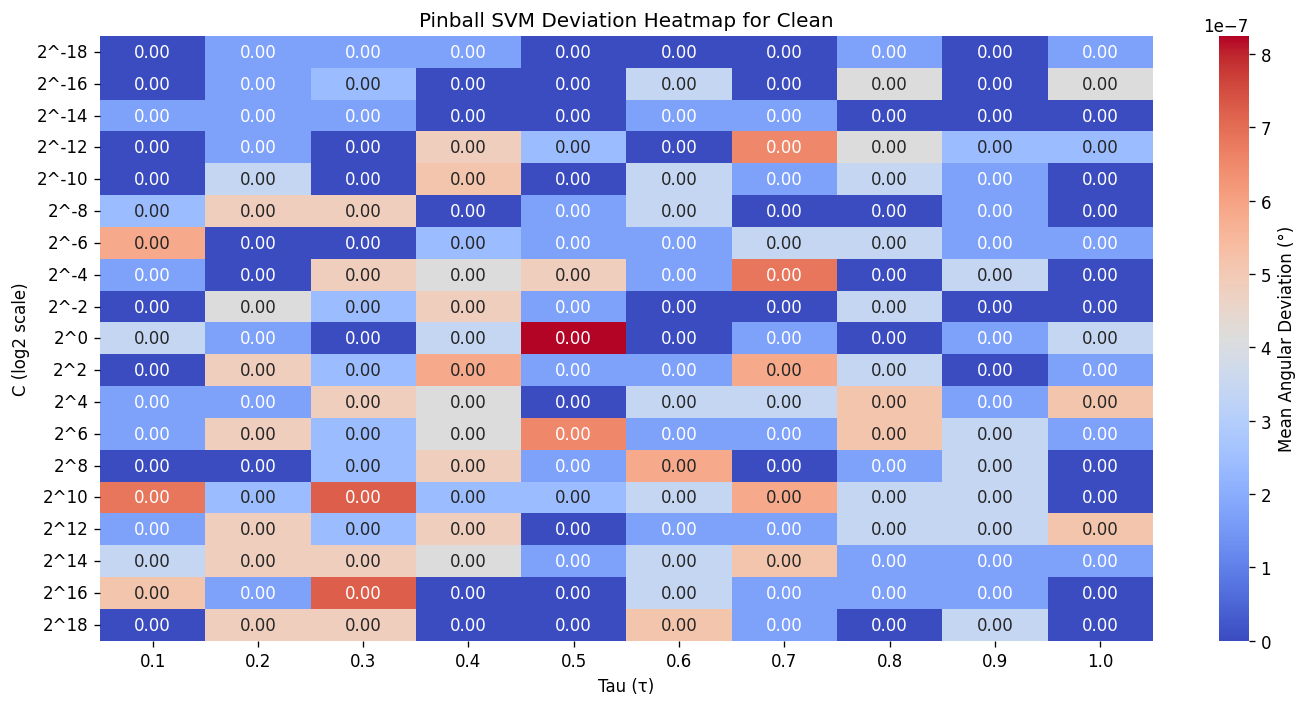

→ Best Params for Clean Outliers: C = 0.0009765625, τ = 1.0, Min Deviation = 0.78°


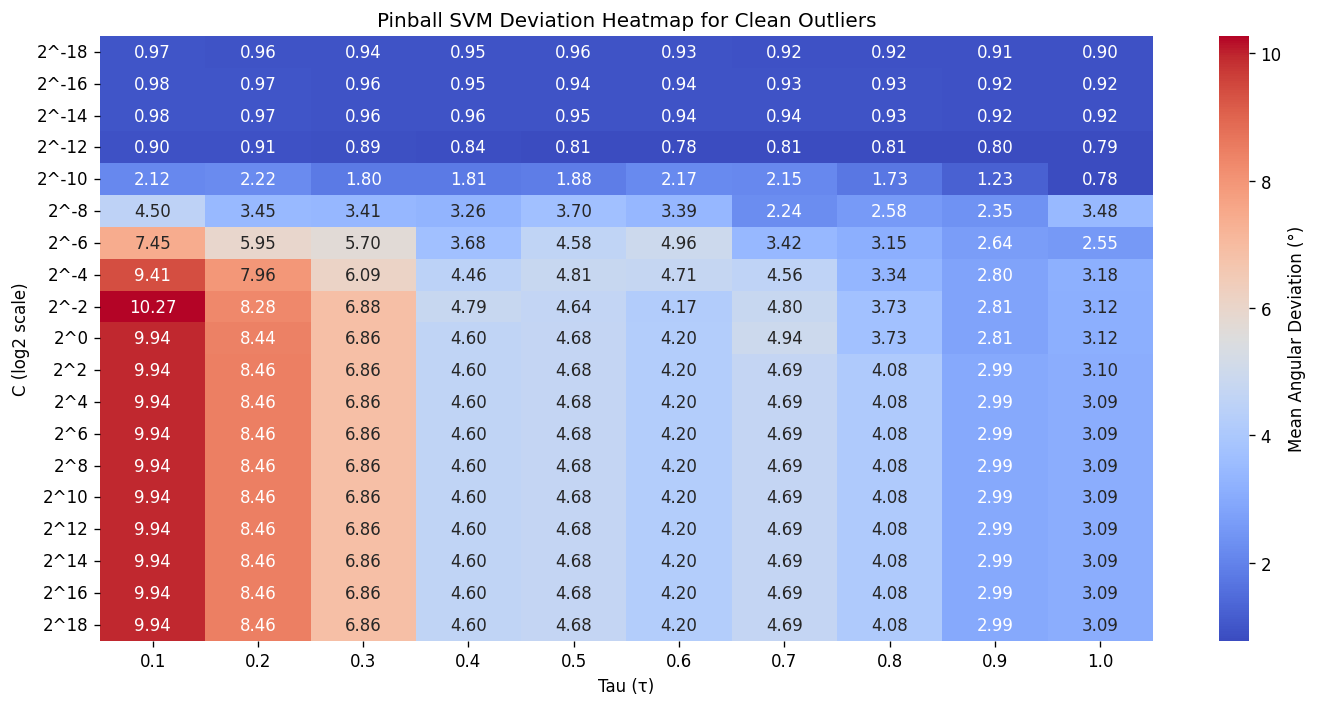

→ Best Params for Uniform Target Noise: C = 3.814697265625e-06, τ = 1.0, Min Deviation = 0.56°


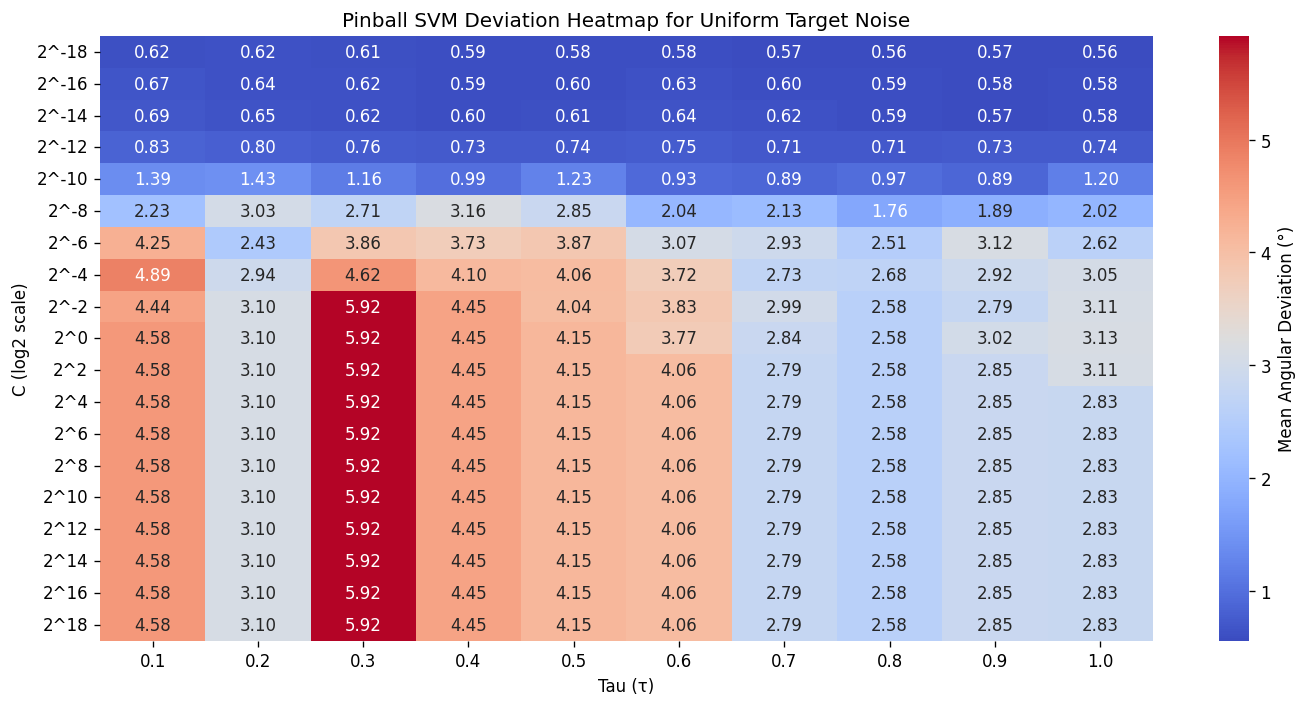

→ Best Params for Gaussian Target Noise: C = 0.0009765625, τ = 0.6, Min Deviation = 5.81°


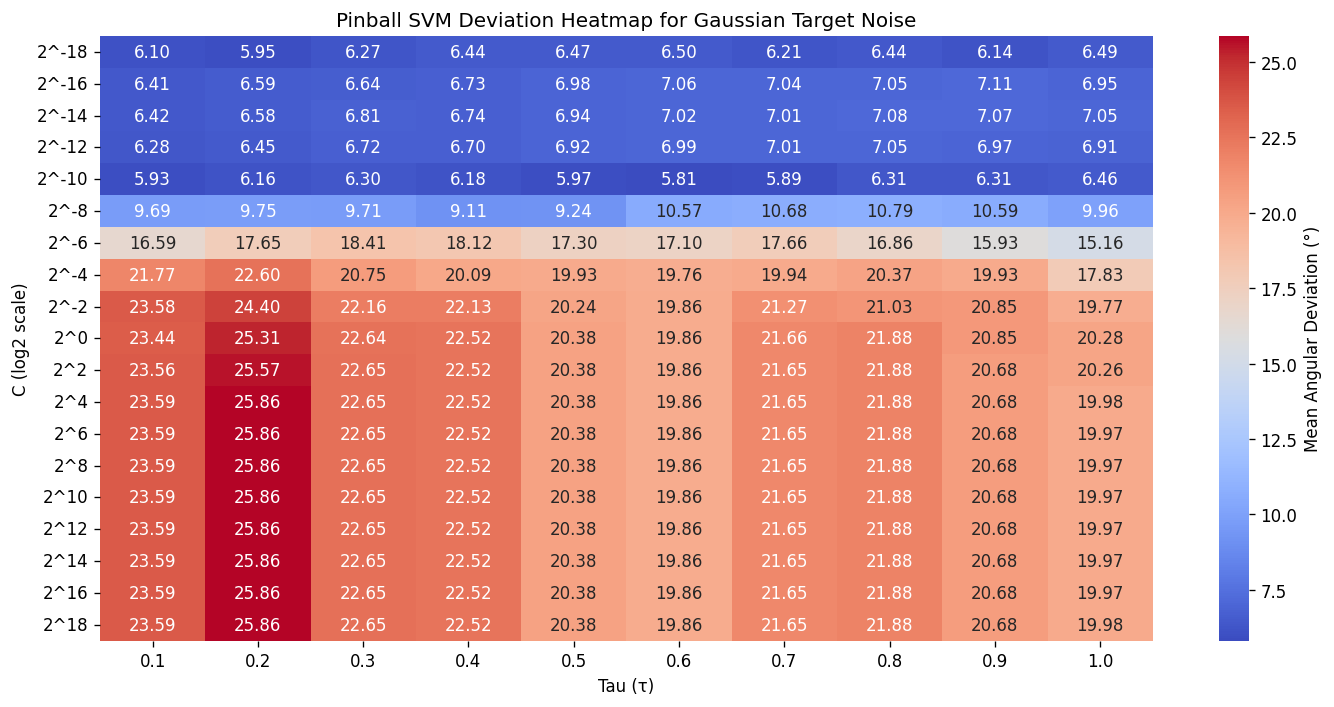

→ Best Params for Feature Noise: C = 3.814697265625e-06, τ = 0.2, Min Deviation = 0.26°


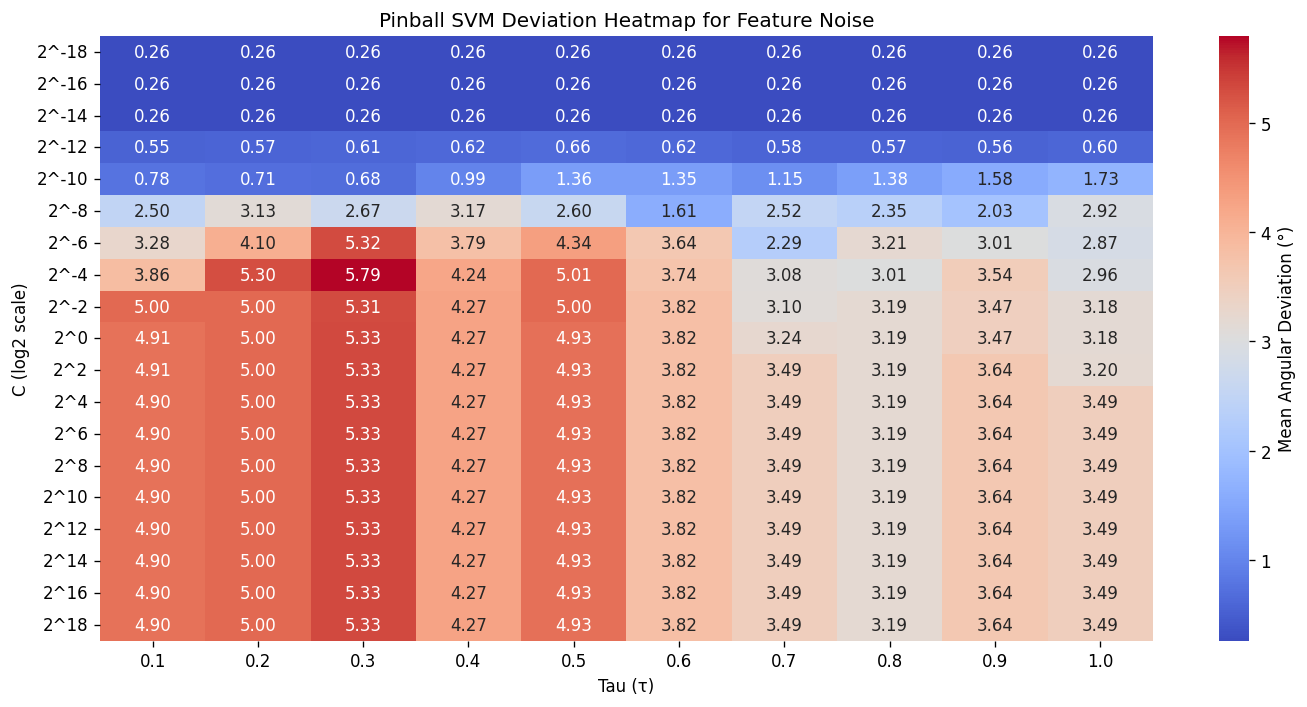

→ Best Params for Uniform Target Noise Outliers: C = 6.103515625e-05, τ = 1.0, Min Deviation = 0.70°


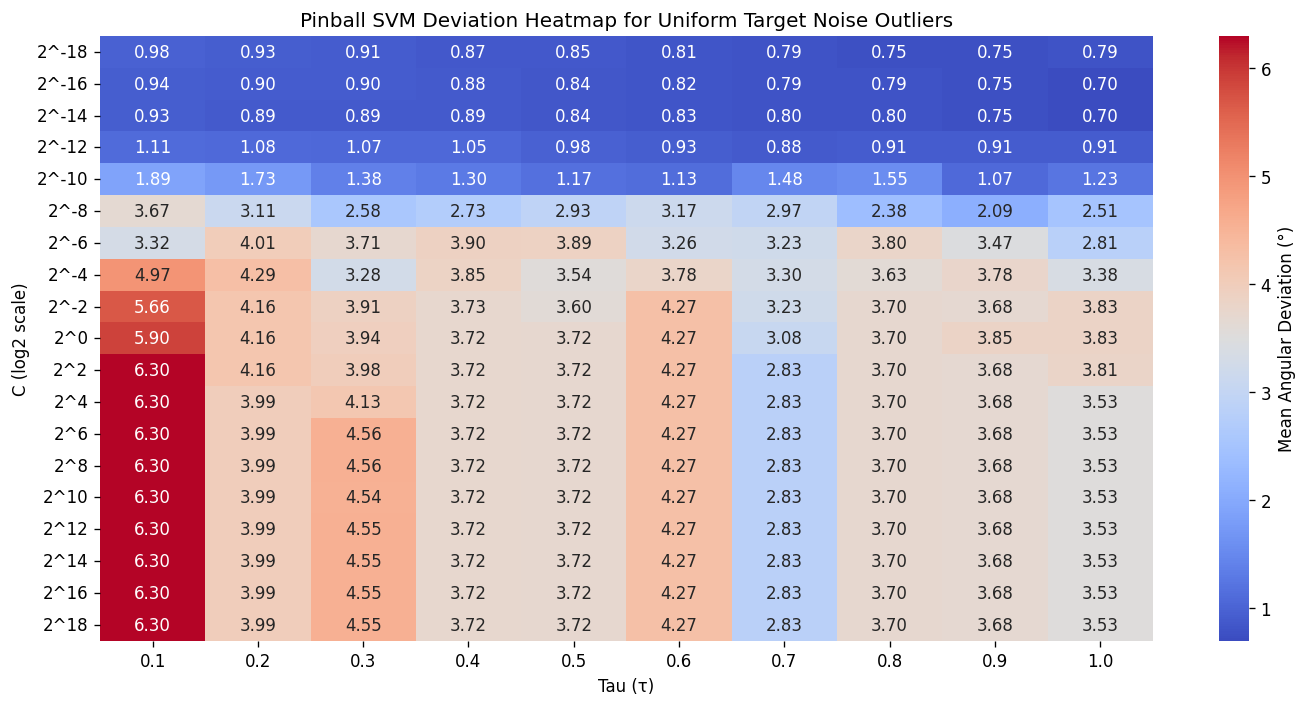

→ Best Params for Gaussian Target Noise Outliers: C = 3.814697265625e-06, τ = 0.2, Min Deviation = 6.00°


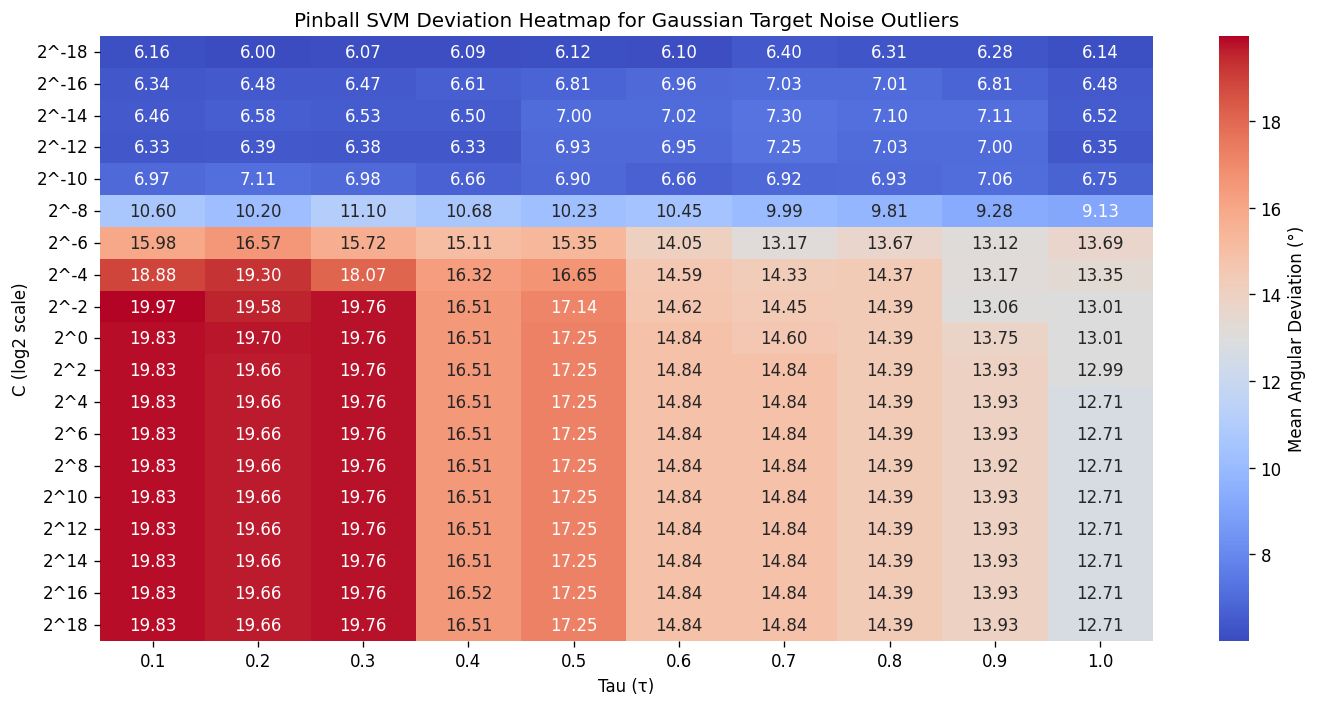

→ Best Params for Feature Noise Outliers: C = 3.814697265625e-06, τ = 0.9, Min Deviation = 0.92°


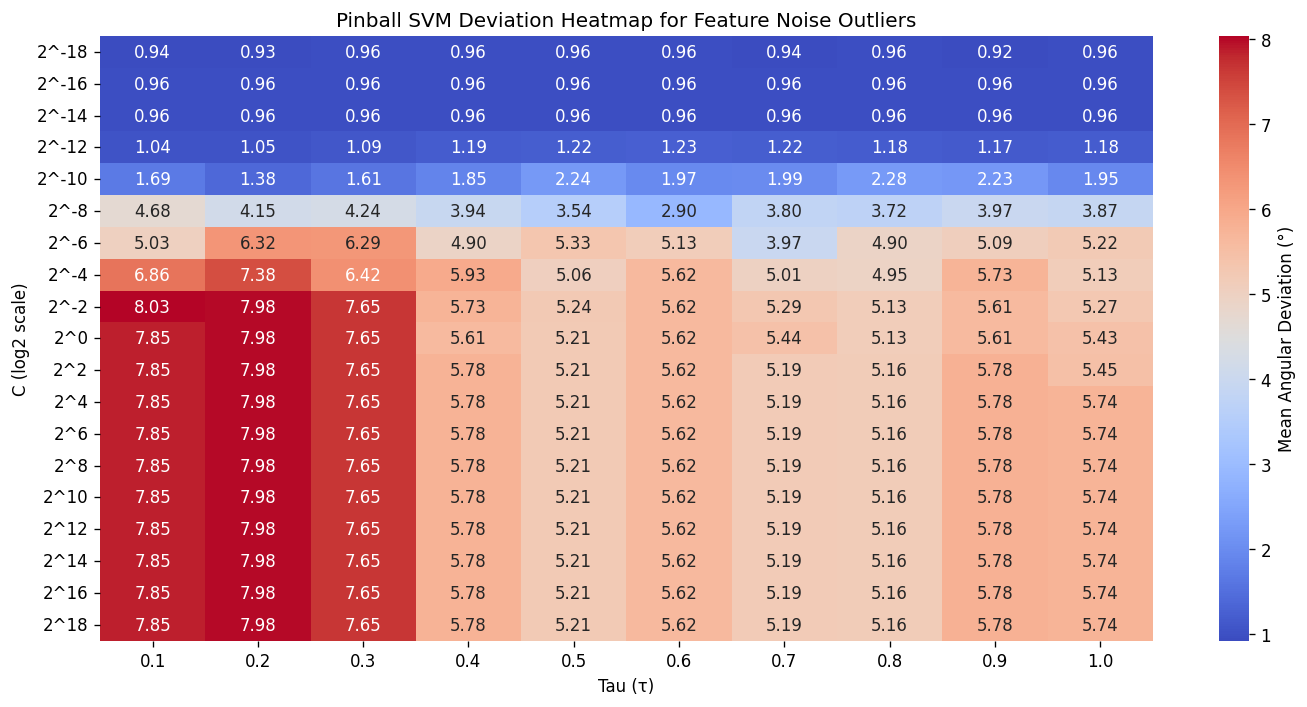

In [ ]:
import seaborn as sns
import pandas as pd

for name in dataset_names:
    heatmap_data = pd.DataFrame(index=[f"2^{i}" for i in C_exp_range], columns=[f"{t:.1f}" for t in tau_values])
    best_dev = float('inf')
    best_C, best_tau = None, None

    for i, C in enumerate(C_values):
        for tau in tau_values:
            deviations = pinball_results[name][tau][C]
            valid_devs = [d for d in deviations if d is not None]
            avg_dev = np.mean(valid_devs) if valid_devs else np.nan
            heatmap_data.loc[f"2^{C_exp_range[i]}", f"{tau:.1f}"] = avg_dev

            if not np.isnan(avg_dev) and avg_dev < best_dev:
                best_dev = avg_dev
                best_C = C
                best_tau = tau

    print(f"→ Best Params for {name.replace('_', ' ').title()}: C = {best_C}, τ = {best_tau}, Min Deviation = {best_dev:.2f}°")

    plt.figure(figsize=(12, 6))
    sns.heatmap(heatmap_data.astype(float), annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Mean Angular Deviation (°)'})
    plt.title(f"Pinball SVM Deviation Heatmap for {name.replace('_', ' ').title()}")
    plt.xlabel("Tau (τ)")
    plt.ylabel("C (log2 scale)")
    plt.tight_layout()
    os.makedirs("pinball_heatmap", exist_ok=True)
    plt.savefig(f"pinball_heatmap/pinball_heatmap_{name}.png", dpi=300)
    plt.show()


# EAGLE

In [ ]:
def eagle_svm_dual(X, y, C=1.0, tau=0.5, psi1=2.5, psi2=1.5):
    n = X.shape[0]
    y = y.reshape(-1, 1)

    K = X @ X.T
    Q = (y @ y.T) * K

    H = np.block([
        [ Q, -Q ],
        [ -Q, Q ]
    ])

    c_alpha = -(psi1 - 1) * np.ones(n)
    c_beta = -(1 - psi2) * np.ones(n)
    c = np.hstack([c_alpha, c_beta])

    Aeq = np.hstack([y.T, -y.T])
    beq = np.array([0.0])

    A2 = np.zeros((n, 2 * n))
    A2[np.arange(n), np.arange(n)] = 1
    A2[np.arange(n), np.arange(n) + n] = 1
    b2 = np.ones(n) * C * tau

    A_combined = np.vstack([Aeq, A2])
    b_combined = np.hstack([beq, b2])

    G = -np.eye(2 * n)
    h = np.zeros(2 * n)

    P = matrix(H)
    q = matrix(c)
    G = matrix(G)
    h = matrix(h)
    A = matrix(A_combined)
    b = matrix(b_combined)

    solvers.options['show_progress'] = False
    sol = solvers.qp(P, q, G, h, A, b)

    result = np.array(sol['x']).flatten()
    alpha = result[:n]
    beta = result[n:]

    return alpha, beta

In [ ]:
C_values = [2**i for i in range(-18, 19, 2)]
tau_values = np.round(np.arange(0.1, 1.0 + 0.1, 0.1), 2)
psi1_values = np.round(np.arange(1.0, 3.1, 0.5), 2)
psi2_values = np.round(np.arange(1.0, 3.1, 0.5), 2)

from itertools import product
eagle_results_grid = {name: {} for name in dataset_names}

for C, tau, psi1, psi2 in product(C_values, tau_values, psi1_values, psi2_values):
    print(f"\nProcessing hyperparameters: C={C}, τ={tau}, ψ₁={psi1}, ψ₂={psi2}")
    key = (C, tau, psi1, psi2)
    for name in dataset_names:
        deviations = []
        for seed in range(5):
            X_cur, y_cur = datasets[name][seed]
            X_clean, y_clean = datasets["clean"][seed]
            try:
                alpha_c, beta_c = eagle_svm_dual(X_cur, y_cur, C, tau, psi1, psi2)
                w_c = np.sum((beta_c - alpha_c)[:, None] * y_cur[:, None] * X_cur, axis=0)

                alpha_cl, beta_cl = eagle_svm_dual(X_clean, y_clean, C, tau, psi1, psi2)
                w_cl = np.sum((beta_cl - alpha_cl)[:, None] * y_clean[:, None] * X_clean, axis=0)

                angle = compute_angle_deviation(w_cl, w_c)
            except:
                angle = None
            deviations.append(angle)
        eagle_results_grid[name][key] = deviations

Streaming output truncated to the last 5000 lines.

Processing hyperparameters: C=1, τ=0.1, ψ₁=1.0, ψ₂=1.0

Processing hyperparameters: C=1, τ=0.1, ψ₁=1.0, ψ₂=1.5

Processing hyperparameters: C=1, τ=0.1, ψ₁=1.0, ψ₂=2.0

Processing hyperparameters: C=1, τ=0.1, ψ₁=1.0, ψ₂=2.5

Processing hyperparameters: C=1, τ=0.1, ψ₁=1.0, ψ₂=3.0

Processing hyperparameters: C=1, τ=0.1, ψ₁=1.5, ψ₂=1.0

Processing hyperparameters: C=1, τ=0.1, ψ₁=1.5, ψ₂=1.5

Processing hyperparameters: C=1, τ=0.1, ψ₁=1.5, ψ₂=2.0

Processing hyperparameters: C=1, τ=0.1, ψ₁=1.5, ψ₂=2.5

Processing hyperparameters: C=1, τ=0.1, ψ₁=1.5, ψ₂=3.0

Processing hyperparameters: C=1, τ=0.1, ψ₁=2.0, ψ₂=1.0

Processing hyperparameters: C=1, τ=0.1, ψ₁=2.0, ψ₂=1.5

Processing hyperparameters: C=1, τ=0.1, ψ₁=2.0, ψ₂=2.0

Processing hyperparameters: C=1, τ=0.1, ψ₁=2.0, ψ₂=2.5

Processing hyperparameters: C=1, τ=0.1, ψ₁=2.0, ψ₂=3.0

Processing hyperparameters: C=1, τ=0.1, ψ₁=2.5, ψ₂=1.0

Processing hyperparameters: C=1, τ=0.1, ψ₁=2.5, ψ₂=1

In [ ]:
from tabulate import tabulate

print("=== Best Hyperparameters per Dataset (Min Avg Angular Deviation) ===")
headers = ["Dataset", "C", "Tau", "Psi1", "Psi2", "Avg. Deviation"]
table = []

for name in dataset_names:
    best = (None, float('inf'))
    for (C, tau, psi1, psi2), devs in eagle_results_grid[name].items():
        devs = [d for d in devs if d is not None]
        if devs:
            avg = np.mean(devs)
            if avg < best[1]:
                best = ((C, tau, psi1, psi2), avg)
    (C, tau, psi1, psi2), deviation = best
    table.append([name, f"{C:.1e}", tau, psi1, psi2, f"{deviation:.2f}"])

print(tabulate(table, headers=headers, tablefmt="grid"))

=== Best Hyperparameters per Dataset (Min Avg Angular Deviation) ===
+--------------------------------+---------+-------+--------+--------+------------------+
| Dataset                        |       C |   Tau |   Psi1 |   Psi2 |   Avg. Deviation |
+================================+=========+=======+========+========+==================+
| clean                          | 3.8e-06 |   0.1 |    1.5 |    1   |             0    |
+--------------------------------+---------+-------+--------+--------+------------------+
| clean_outliers                 | 0.00024 |   0.7 |    2   |    1.5 |             0.65 |
+--------------------------------+---------+-------+--------+--------+------------------+
| uniform_target_noise           | 3.8e-06 |   0.6 |    3   |    2.5 |             0.53 |
+--------------------------------+---------+-------+--------+--------+------------------+
| gaussian_target_noise          | 3.8e-06 |   0.1 |    1.5 |    1   |             4.58 |
+------------------------------

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("eagle_best_plots", exist_ok=True)

best_params = {
    "clean": (0.1, 1.5, 1.0),
    "clean_outliers": (0.7, 2.0, 1.5),
    "uniform_target_noise": (0.6, 3.0, 2.5),
    "gaussian_target_noise": (0.1, 1.5, 1.0),
    "feature_noise": (0.1, 1.5, 1.0),
    "uniform_target_noise_outliers": (0.9, 2.0, 3.0),
    "gaussian_target_noise_outliers": (0.1, 3.0, 3.0),
    "feature_noise_outliers": (1.0, 2.0, 3.0)
}

for dataset_name, (tau, psi1, psi2) in best_params.items():
    plt.figure(figsize=(10, 6))

    for name in dataset_names:
        y_means = []
        for C in C_values:
            key = (C, tau, psi1, psi2)
            devs = eagle_results_grid[name].get(key, [])
            devs = [d for d in devs if d is not None]
            y_means.append(np.mean(devs) if devs else np.nan)

        plt.plot(C_values, y_means, marker='o', linestyle='--', label=name.replace('_', ' ').title())

    plt.xscale('log')
    plt.xlabel("C (Regularization Parameter)")
    plt.ylabel("Mean Angular Deviation (degrees)")
    plt.title(f"Deviation vs C across Datasets\nFixed Params: τ={tau}, ψ₁={psi1}, ψ₂={psi2}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc="upper right", fontsize=8)
    plt.tight_layout()

    fname = f"eagle_best_plots/ALL_at_bestparams_for_{dataset_name}_tau_{tau}_psi1_{psi1}_psi2_{psi2}.png"
    plt.savefig(fname, dpi=300)
    plt.close()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("eagle_ctau_heatmaps", exist_ok=True)

best_params = {
    "clean": (0.1, 1.5, 1.0),
    "clean_outliers": (0.7, 2.0, 1.5),
    "uniform_target_noise": (0.6, 3.0, 2.5),
    "gaussian_target_noise": (0.1, 1.5, 1.0),
    "feature_noise": (0.1, 1.5, 1.0),
    "uniform_target_noise_outliers": (0.9, 2.0, 3.0),
    "gaussian_target_noise_outliers": (0.1, 3.0, 3.0),
    "feature_noise_outliers": (1.0, 2.0, 3.0)
}

for dataset_name, (best_tau, psi1, psi2) in best_params.items():
    heatmap_data = np.zeros((len(tau_values), len(C_values)))

    for i, tau in enumerate(tau_values):
        for j, C in enumerate(C_values):
            key = (C, tau, psi1, psi2)
            devs = eagle_results_grid[dataset_name].get(key, [])
            valid = [d for d in devs if d is not None]
            heatmap_data[i, j] = np.mean(valid) if valid else np.nan

    if np.isnan(heatmap_data).all():
        print(f"⚠️ Skipping heatmap for {dataset_name} | ψ₁={psi1}, ψ₂={psi2} (all NaNs)")
        continue

    plt.figure(figsize=(12, 6))
    sns.heatmap(
        heatmap_data,
        annot=True, fmt=".2f", cmap="coolwarm",
        xticklabels=[f"{C:.0e}" for C in C_values],
        yticklabels=[f"{tau:.1f}" for tau in tau_values]
    )

    plt.title(f"Deviation Heatmap for {dataset_name.replace('_', ' ').title()}\nFixed: ψ₁={psi1}, ψ₂={psi2}")
    plt.xlabel("C (Regularization Parameter)")
    plt.ylabel("Tau (Asymmetry Parameter)")
    plt.tight_layout()

    fname = f"eagle_ctau_heatmaps/eagle_heatmap_{dataset_name}_psi1_{psi1}_psi2_{psi2}.png"
    plt.savefig(fname, dpi=300)
    plt.close()